<a href="https://colab.research.google.com/github/VER2E/NEUR3002-In-class-Activities/blob/main/ICA_2_Integrate_and_Fire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Below is Python code that runs an Integrate and Fire Model, Take some time to investigate the code and then complete the worksheet on Canvas titled "Worksheet 2, Integrate & Fire"

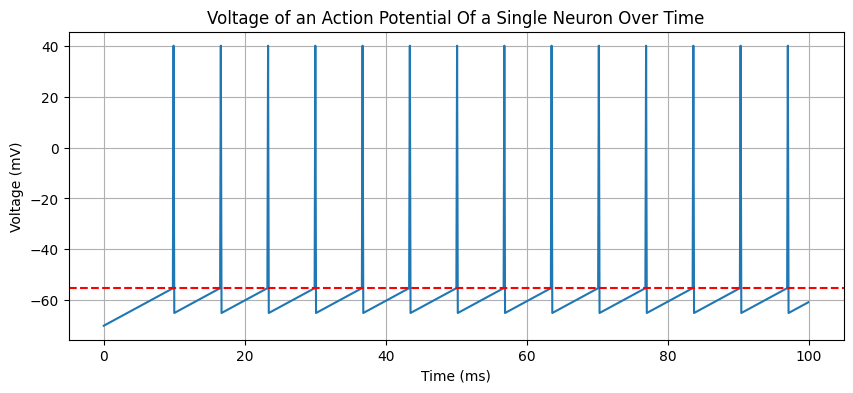

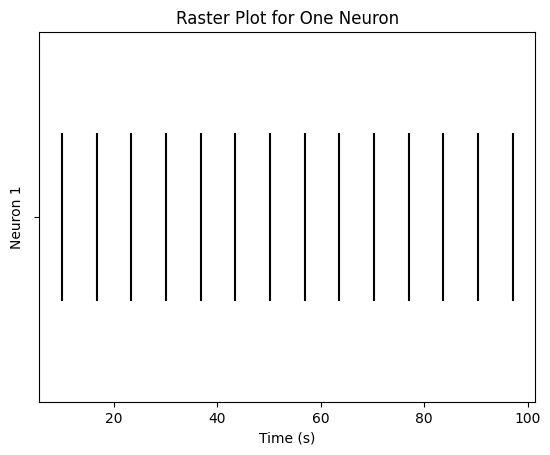

In [ ]:
# Jupyter: enable plot rendering inside the notebook (this allows us to actually show the output of the code visually)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# --- Neuron Parameters (realistic, in mV and pA) ---
C = 200.0 # capacitance (separator of charge) determined by lipid bilayer
V_th = -55 # threshold of action potential, in mV
V_reset = -65.0 # hyperpolarization, hence the "reset", in mV
V_rest = -70.0 # resting potential in mV
I_ext = 300.0 # external current, in pA
dt = 0.1 #change in time, or time step in ms


T = 100          # total simulation time in ms
dt = 0.1         # time step in ms
time = np.arange(0, T, dt)  # time vector

# --- Initialize voltage and spike times ---
V = np.full_like(time, V_rest)  # set all values to resting voltage
spike_times = []

# --- Simulation---
for i in range(1, len(time)):
    dV = (I_ext / C) * dt       # ΔV = (I / C) * dt, in mV
    V[i] = V[i-1] + dV

    if V[i] >= V_th:
        V[i-1] = 40.0           # mark spike as +40 mV (for visualization)
        V[i] = V_reset
        spike_times.append(time[i])

# --- Plotting mV vs. mS ---
plt.figure(figsize=(10, 4))
plt.plot(time, V, label='fix meZ')
plt.axhline(V_th, color='r', linestyle='--', label='Threshold')
plt.xlabel('Time (ms)') #what should the x be?
plt.ylabel('Voltage (mV)') #what should the y be?
plt.title('Voltage of an Action Potential Of a Single Neuron Over Time') #what is a good title?
plt.grid(True)
plt.show()

# --- Plotting Raster Plot ---
plt.eventplot([spike_times], colors='black')
plt.yticks([1], [''])
plt.xlabel('Time (s)') # Label for x
plt.ylabel('Neuron 1') # Label for y
plt.title('Raster Plot for One Neuron') # Title
plt.show()
